In [1]:
import os
import math
import copy
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn, Tensor

import warnings
from collections import namedtuple
from typing import Any, Callable, List, Optional, Tuple

In [2]:
InceptionOutputs = namedtuple("InceptionOutputs", ["logits", "aux_logits"])
InceptionOutputs.__annotations__ = {"logits": Tensor, "aux_logits": Optional[Tensor]}


class Inception3(nn.Module):
    def __init__(
        self,
        num_classes: int = 3,
        aux_logits: bool = True,
        transform_input: bool = False,
        #inception_blicks: Optional[List[Callable[..., nn.Module]]] = None,
        init_weights: Optional[bool] = None,
        dropout: float = 0.5,
    ) -> None:
        super().__init__()
        inception_blocks = [BasicConv3d, InceptionA, InceptionB, InceptionC, InceptionD, InceptionE, InceptionAux]
        conv_block = inception_blocks[0]
        inception_a = inception_blocks[1]
        inception_b = inception_blocks[2]
        inception_c = inception_blocks[3]
        inception_d = inception_blocks[4]
        inception_e = inception_blocks[5]
        inception_aux = inception_blocks[6]
        
        self.aux_logits = aux_logits
        self.transform_input = transform_input
        self.Conv3d_1a_3x3 = conv_block(1, 32, kernel_size=3, stride=2, padding=1)
        self.Conv3d_2a_3x3 = conv_block(32, 64, kernel_size=3, padding=1)
        self.Conv3d_2b_3x3 = conv_block(64, 192, kernel_size=3, padding=1)
        self.maxpool1 = nn.MaxPool3d(kernel_size=3, stride=2, padding=1)
        self.Mixed_5b = inception_a(192, pool_features=32)
        self.Mixed_5c = inception_a(256, pool_features=64)
        self.Mixed_5d = inception_a(288, pool_features=64)
        self.Mixed_6a = inception_b(288)
        self.Mixed_6b = inception_c(768, channels_7x7=128)
        self.Mixed_6c = inception_c(768, channels_7x7=160)
        self.Mixed_6d = inception_c(768, channels_7x7=160)
        self.Mixed_6e = inception_c(768, channels_7x7=192)
        self.AuxLogits: Optional[nn.Module] = None
        if aux_logits:
            self.AuxLogits = inception_aux(768, num_classes)
        self.Mixed_7a = inception_d(768)
        self.Mixed_7b = inception_e(1280)
        self.Mixed_7c = inception_e(2048)
        self.avgpool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(2048, num_classes)
        
        if init_weights:
            for m in self.modules():
                if isinstance(m, nn.Conv3d) or isinstance(m, nn.Linear):
                    stddev = float(m.stddev) if hasattr(m, "stddev") else 0.1  # type: ignore
                    torch.nn.init.trunc_normal_(m.weight, mean=0.0, std=stddev, a=-2, b=2)
                elif isinstance(m, nn.BatchNorm3d):
                    nn.init.constant_(m.weight, 1)
                    nn.init.constant_(m.bias, 0)

    def _forward(self, x: Tensor) -> Tuple[Tensor, Optional[Tensor]]:
        x = self.Conv3d_1a_3x3(x)
        x = self.Conv3d_2a_3x3(x)
        x = self.Conv3d_2b_3x3(x)
        x = self.maxpool1(x)
        x = self.Mixed_5b(x)
        x = self.Mixed_5c(x)
        x = self.Mixed_5d(x)
        x = self.Mixed_6a(x)
        x = self.Mixed_6b(x)
        x = self.Mixed_6c(x)
        x = self.Mixed_6d(x)
        x = self.Mixed_6e(x)
        aux: Optional[Tensor] = None
        if self.AuxLogits is not None:
            if self.training:
                aux = self.AuxLogits(x)
        x = self.Mixed_7a(x)
        x = self.Mixed_7b(x)
        x = self.Mixed_7c(x)
        x = self.avgpool(x)
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x, aux
    
    @torch.jit.unused
    def eager_outputs(self, x: Tensor, aux: Optional[Tensor]) -> InceptionOutputs:
        if self.training and self.aux_logits:
            return InceptionOutputs(x, aux)
        else:
            return x

    def forward(self, x: Tensor) -> InceptionOutputs:
        x, aux = self._forward(x)
        aux_defined = self.training and self.aux_logits
        if torch.jit.is_scripting():
            if not aux_defined:
                warnings.warn("Scripted Inception3 always returns Inception3 Tuple")
            return InceptionOutputs(x, aux)
        else:
            return self.eager_outputs(x, aux)


class InceptionA(nn.Module):
    def __init__(
        self, in_channels: int, pool_features: int, conv_block: Optional[Callable[..., nn.Module]] = None
    ) -> None:
        super().__init__()
        if conv_block is None:
            conv_block = BasicConv3d
        self.branch1x1 = conv_block(in_channels, 64, kernel_size=1)

        self.branch5x5_1 = conv_block(in_channels, 48, kernel_size=1)
        self.branch5x5_2 = conv_block(48, 64, kernel_size=5, padding=2)

        self.branch3x3dbl_1 = conv_block(in_channels, 64, kernel_size=1)
        self.branch3x3dbl_2 = conv_block(64, 96, kernel_size=3, padding=1)
        self.branch3x3dbl_3 = conv_block(96, 96, kernel_size=3, padding=1)

        self.branch_pool = conv_block(in_channels, pool_features, kernel_size=1)

    def _forward(self, x: Tensor) -> List[Tensor]:
        branch1x1 = self.branch1x1(x)

        branch5x5 = self.branch5x5_1(x)
        branch5x5 = self.branch5x5_2(branch5x5)

        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = self.branch3x3dbl_3(branch3x3dbl)

        branch_pool = F.avg_pool3d(x, kernel_size=3, stride=1, padding=1)
        branch_pool = self.branch_pool(branch_pool)

        outputs = [branch1x1, branch5x5, branch3x3dbl, branch_pool]
        return outputs

    def forward(self, x: Tensor) -> Tensor:
        outputs = self._forward(x)
        return torch.cat(outputs, 1)


class InceptionB(nn.Module):
    def __init__(self, in_channels: int, conv_block: Optional[Callable[..., nn.Module]] = None) -> None:
        super().__init__()
        if conv_block is None:
            conv_block = BasicConv3d
        self.branch3x3 = conv_block(in_channels, 384, kernel_size=3, stride=2)

        self.branch3x3dbl_1 = conv_block(in_channels, 64, kernel_size=1)
        self.branch3x3dbl_2 = conv_block(64, 96, kernel_size=3, padding=1)
        self.branch3x3dbl_3 = conv_block(96, 96, kernel_size=3, stride=2)

    def _forward(self, x: Tensor) -> List[Tensor]:
        branch3x3 = self.branch3x3(x)

        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = self.branch3x3dbl_3(branch3x3dbl)

        branch_pool = F.max_pool3d(x, kernel_size=3, stride=2)

        outputs = [branch3x3, branch3x3dbl, branch_pool]
        return outputs

    def forward(self, x: Tensor) -> Tensor:
        outputs = self._forward(x)
        return torch.cat(outputs, 1)


class InceptionC(nn.Module):
    def __init__(
        self, in_channels: int, channels_7x7: int, conv_block: Optional[Callable[..., nn.Module]] = None
    ) -> None:
        super().__init__()
        if conv_block is None:
            conv_block = BasicConv3d
        self.branch1x1 = conv_block(in_channels, 192, kernel_size=1)

        c7 = channels_7x7
        self.branch7x7_1 = conv_block(in_channels, c7, kernel_size=1)
        self.branch7x7_2 = conv_block(c7, c7, kernel_size=(1, 1, 7), padding=(0, 0, 3))
        self.branch7x7_3 = conv_block(c7, c7, kernel_size=(1, 7, 1), padding=(0, 3, 0))
        self.branch7x7_4 = conv_block(c7, 192, kernel_size=(7, 1, 1), padding=(3, 0, 0))

        self.branch7x7dbl_1 = conv_block(in_channels, c7, kernel_size=1)
        self.branch7x7dbl_2 = conv_block(c7, c7, kernel_size=(1, 1, 7), padding=(0, 0, 3))
        self.branch7x7dbl_3 = conv_block(c7, c7, kernel_size=(1, 7, 1), padding=(0, 3, 0))
        self.branch7x7dbl_4 = conv_block(c7, c7, kernel_size=(7, 1, 1), padding=(3, 0, 0))
        self.branch7x7dbl_5 = conv_block(c7, c7, kernel_size=(1, 1, 7), padding=(0, 0, 3))
        self.branch7x7dbl_6 = conv_block(c7, c7, kernel_size=(1, 7, 1), padding=(0, 3, 0))
        self.branch7x7dbl_7 = conv_block(c7, 192, kernel_size=(7, 1, 1), padding=(3, 0, 0))

        self.branch_pool = conv_block(in_channels, 192, kernel_size=1)

    def _forward(self, x: Tensor) -> List[Tensor]:
        branch1x1 = self.branch1x1(x)

        branch7x7 = self.branch7x7_1(x)
        branch7x7 = self.branch7x7_2(branch7x7)
        branch7x7 = self.branch7x7_3(branch7x7)
        branch7x7 = self.branch7x7_4(branch7x7)

        branch7x7dbl = self.branch7x7dbl_1(x)
        branch7x7dbl = self.branch7x7dbl_2(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_3(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_4(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_5(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_6(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_7(branch7x7dbl)

        branch_pool = F.avg_pool3d(x, kernel_size=3, stride=1, padding=1)
        branch_pool = self.branch_pool(branch_pool)

        outputs = [branch1x1, branch7x7, branch7x7dbl, branch_pool]
        return outputs

    def forward(self, x: Tensor) -> Tensor:
        outputs = self._forward(x)
        return torch.cat(outputs, 1)


class InceptionD(nn.Module):
    def __init__(self, in_channels: int, conv_block: Optional[Callable[..., nn.Module]] = None) -> None:
        super().__init__()
        if conv_block is None:
            conv_block = BasicConv3d
        self.branch3x3_1 = conv_block(in_channels, 192, kernel_size=1)
        self.branch3x3_2 = conv_block(192, 320, kernel_size=3, stride=2)

        self.branch7x7x3_1 = conv_block(in_channels, 192, kernel_size=1)
        self.branch7x7x3_2 = conv_block(192, 192, kernel_size=(1, 1, 7), padding=(0, 0, 3))
        self.branch7x7x3_3 = conv_block(192, 192, kernel_size=(1, 7, 1), padding=(0, 3, 0))
        self.branch7x7x3_4 = conv_block(192, 192, kernel_size=(7, 1, 1), padding=(3, 0, 0))
        self.branch7x7x3_5 = conv_block(192, 192, kernel_size=3, stride=2)

    def _forward(self, x: Tensor) -> List[Tensor]:
        branch3x3 = self.branch3x3_1(x)
        branch3x3 = self.branch3x3_2(branch3x3)

        branch7x7x3 = self.branch7x7x3_1(x)
        branch7x7x3 = self.branch7x7x3_2(branch7x7x3)
        branch7x7x3 = self.branch7x7x3_3(branch7x7x3)
        branch7x7x3 = self.branch7x7x3_4(branch7x7x3)
        branch7x7x3 = self.branch7x7x3_5(branch7x7x3)

        branch_pool = F.max_pool3d(x, kernel_size=3, stride=2)
        outputs = [branch3x3, branch7x7x3, branch_pool]
        return outputs

    def forward(self, x: Tensor) -> Tensor:
        outputs = self._forward(x)
        return torch.cat(outputs, 1)


class InceptionE(nn.Module):
    def __init__(self, in_channels: int, conv_block: Optional[Callable[..., nn.Module]] = None) -> None:
        super().__init__()
        if conv_block is None:
            conv_block = BasicConv3d
        self.branch1x1 = conv_block(in_channels, 320, kernel_size=1)

        self.branch3x3_1 = conv_block(in_channels, 256, kernel_size=1)
        self.branch3x3_2a = conv_block(256, 256, kernel_size=(1, 1, 3), padding=(0, 0, 1))
        self.branch3x3_2b = conv_block(256, 256, kernel_size=(1, 3, 1), padding=(0, 1, 0))
        self.branch3x3_2c = conv_block(256, 256, kernel_size=(3, 1, 1), padding=(1, 0, 0))

        self.branch3x3dbl_1 = conv_block(in_channels, 448, kernel_size=1)
        self.branch3x3dbl_2 = conv_block(448, 256, kernel_size=3, padding=1)
        self.branch3x3dbl_3a = conv_block(256, 256, kernel_size=(1, 1, 3), padding=(0, 0, 1))
        self.branch3x3dbl_3b = conv_block(256, 256, kernel_size=(1, 3, 1), padding=(0, 1, 0))
        self.branch3x3dbl_3c = conv_block(256, 256, kernel_size=(3, 1, 1), padding=(1, 0, 0))

        self.branch_pool = conv_block(in_channels, 192, kernel_size=1)

    def _forward(self, x: Tensor) -> List[Tensor]:
        branch1x1 = self.branch1x1(x)

        branch3x3 = self.branch3x3_1(x)
        branch3x3 = [
            self.branch3x3_2a(branch3x3),
            self.branch3x3_2b(branch3x3),
            self.branch3x3_2c(branch3x3),
        ]
        branch3x3 = torch.cat(branch3x3, 1)

        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = [
            self.branch3x3dbl_3a(branch3x3dbl),
            self.branch3x3dbl_3b(branch3x3dbl),
            self.branch3x3dbl_3c(branch3x3dbl),
        ]
        branch3x3dbl = torch.cat(branch3x3dbl, 1)

        branch_pool = F.avg_pool3d(x, kernel_size=3, stride=1, padding=1)
        branch_pool = self.branch_pool(branch_pool)

        outputs = [branch1x1, branch3x3, branch3x3dbl, branch_pool]
        return outputs

    def forward(self, x: Tensor) -> Tensor:
        outputs = self._forward(x)
        return torch.cat(outputs, 1)


class InceptionAux(nn.Module):
    def __init__(
        self, in_channels: int, num_classes: int, conv_block: Optional[Callable[..., nn.Module]] = None
    ) -> None:
        super().__init__()
        if conv_block is None:
            conv_block = BasicConv3d
        self.conv0 = conv_block(in_channels, 128, kernel_size=1)
        self.conv1 = conv_block(128, 768, kernel_size=3)
        self.conv1.stddev = 0.01
        self.fc = nn.Linear(768, num_classes)
        self.fc.stddev = 0.001

    def forward(self, x: Tensor) -> Tensor:
        x = F.avg_pool3d(x, kernel_size=3, stride=2)
        x = self.conv0(x)
        x = self.conv1(x)
        x = F.adaptive_avg_pool3d(x, (1, 1, 1))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
          

class BasicConv3d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs: Any) -> None:
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm3d(out_channels, eps=0.001)

    def forward(self, x: Tensor) -> Tensor:
        x = self.conv(x)
        x = self.bn(x)
        return F.relu(x, inplace=True)

In [3]:
class Baseline(nn.Module):
    def __init__(self, num_classes: int = 3, init_weights: Optional[bool] = True):
        super().__init__()
        self.Conv3d_1 = BasicConv3d(1, 32, kernel_size=3, stride=2)
        self.Conv3d_2 = BasicConv3d(32, 64, kernel_size=3)
        self.maxpool1 = nn.MaxPool3d(kernel_size=3, stride=2)
        self.Conv3d_3 = BasicConv3d(64, 128, kernel_size=1)
        self.Conv3d_4 = BasicConv3d(128, 256, kernel_size=3)
        self.avgpool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.fc = nn.Linear(256, num_classes)
        
        if init_weights:
            for m in self.modules():
                if isinstance(m, nn.Conv3d) or isinstance(m, nn.Linear):
                    stddev = float(m.stddev) if hasattr(m, "stddev") else 0.1
                    torch.nn.init.trunc_normal_(m.weight, mean=0.0, std=stddev, a=-2, b=2)
                elif isinstance(m, nn.BatchNorm3d):
                    nn.init.constant_(m.weight, 1)
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x: Tensor) -> Tensor:
        x = self.Conv3d_1(x)
        x = self.Conv3d_2(x)
        x = self.maxpool1(x)
        x = self.Conv3d_3(x)
        x = self.Conv3d_4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [4]:
def clone_module_list(module, n: int):
    """
    Make a `nn.ModuleList` with clones of a given module
    """
    return [copy.deepcopy(module) for _ in range(n)]


class PatchEmbeddings(nn.Module):
    
    def __init__(self, d_model: int, patch_size: int, in_channels: int):
        """
        d_model - the transformer embeddings size
        patch_size - the size of the patch
        in_channels - the number of channels in the input image (3 for rgb)
        """
        super().__init__()
        self.conv = nn.Conv3d(in_channels, d_model, patch_size, stride=patch_size)
        
    def forward(self, x: torch.Tensor):
        """
        x - the input image of shape [batch_size, channels, height, width, deepth]
        """
        x = self.conv(x)
        bs, c, h, w, d = x.shape
        # Rerrange to shape [patches, batch_size, d_model]
        x = x.permute(2, 3, 4, 0, 1)
        x = x.view(h * w * d, bs, c)
        return x


class LearnedPositionalEmbeddings(nn.Module):
    
    def __init__(self, d_model: int, max_len: int = 5000):
        """
        d_model - the transformer embeddings size
        max_len - the maximum number of patches
        """
        super().__init__()
        # Positional embeddings for each location
        self.positional_encodings = nn.Parameter(torch.zeros(max_len, 1, d_model), requires_grad=True)
        
    def forward(self, x: torch.Tensor):
        """
        x - the patch embeddings of shape [patches, batch_size, d_model]
        """
        pe = self.positional_encodings[:x.shape[0]]
        # Add positional embeddings to patch embeddings
        return x + pe


class ClassificationHead(nn.Module):
    
    def __init__(self, d_model: int, n_hidden: int , n_classes: int):
        """
        d_model - the transformer embedding size
        n_hidden - the size of the hidden layer
        n_classes is the number of classes in the classification task
        """
        super().__init__()
        self.linear1 = nn.Linear(d_model, n_hidden)
        self.act = nn.GELU()
        self.linear2 = nn.Linear(n_hidden, n_classes)
        
    def forward(self, x: torch.Tensor):
        """
        x - the transformer encoding for CLS token
        """
        x = self.act(self.linear1(x))
        x = self.linear2(x)
        return x

    
class VisionTransformer(nn.Module):
    
    def __init__(self, d_model, transformer_layer: nn.TransformerEncoderLayer, n_layers: int,
                 patch_emb: PatchEmbeddings, pos_emb: LearnedPositionalEmbeddings,
                 classification: ClassificationHead):
        """
        d_model - the transformer embedding size
        transformer_layer - a copy of a single transformer layer
        n_layers - the number of transformer layers
        patch_emb - the patch embeddings layer
        pos_emb - the positional embeddings layer
        classification - the classification head
        """
        super().__init__()
        self.patch_emb = patch_emb
        self.pos_emb = pos_emb
        self.classification = classification
        self.transformer_layers = clone_module_list(transformer_layer, n_layers)
        self.cls_token_emb = nn.Parameter(torch.randn(1, 1, d_model), requires_grad=True)
        self.ln = nn.LayerNorm([d_model])
        
    def forward(self, x: torch.Tensor):
        """
        x - the input image of shape [batch_size, channels, height, width, deepth]
        """
        x = self.patch_emb(x)
        x = self.pos_emb(x)
        # Concatenate the [CLS] token embeddings before feeding the transformer
        cls_token_emb = self.cls_token_emb.expand(-1, x.shape[1], -1)
        x = torch.cat([cls_token_emb, x])
        
        # Pass through transformer layers with no attention masking
        for layer in self.transformer_layers:
            x = layer(x)
            
        # Get the transformer output of the [CLS] token (which is the first in the sequence)
        x = x[0]
        x = self.ln(x)
        x = self.classification(x)
        return x

In [5]:
class CuboidsDataset(torch.utils.data.Dataset):
    
    def __init__(self, root_dir, transform=None):
        """
        root_dir - directory with all the cuboids
        transform - transform to be applied on a sample
        """
        self.root_dir = root_dir
        self.dirs = next(os.walk(root_dir))[1]
        self.num_classes = len(self.dirs)
        self.transform = transform
        
        self.file_names = []
        for dir_ in self.dirs:
            files = os.listdir(os.path.join(root_dir, dir_))
            files = list(map(lambda x: os.path.join(root_dir, dir_, x), files))
            self.file_names.append(files)
        self.labels = [[i] * len(elem) for i, elem in enumerate(self.file_names)]

        self.file_names = np.concatenate(self.file_names)
        self.labels = np.concatenate(self.labels)

    def __len__(self):
        return len(self.file_names)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        file_path = self.file_names[idx]
        sample = torch.from_numpy(np.load(file_path, mmap_mode='r'))
        label = self.labels[idx]
        
        if self.transform:
            sample = self.transform(sample)
        
        return sample, label


def generator(loader):
    while True:
        for batch in loader:
            yield batch

In [6]:
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

train_root_dir = r'C:\Users\conon\Jupyter\MBMU\generated_cuboids\train'
val_root_dir = r'C:\Users\conon\Jupyter\MBMU\generated_cuboids\val'

n_epochs = 100
batch_size = 16

train_ds = CuboidsDataset(train_root_dir)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)

val_ds = CuboidsDataset(val_root_dir)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=True, drop_last=True)

# Number of GPUs available (0 for CPU mode)
n_gpu = 1
device = torch.device("cuda:0" if (torch.cuda.is_available() and n_gpu > 0) else "cpu")

#net = Baseline().to(device)
#net = Inception3(init_weights=True, aux_logits=True).to(device)
d_model = 768
n_head = 12
dim_feedforward = 3072
n_layers = 6
path_size = 8
in_channels = 1
transformer_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, dim_feedforward=dim_feedforward).to(device)
patch_emb = PatchEmbeddings(d_model=d_model, patch_size=path_size, in_channels=in_channels).to(device)
pos_emb = LearnedPositionalEmbeddings(d_model=d_model).to(device)
classification = ClassificationHead(d_model, n_hidden=2, n_classes=3).to(device)
net = VisionTransformer(
    d_model=d_model,
    transformer_layer=transformer_layer,
    n_layers=n_layers,
    patch_emb=patch_emb,
    pos_emb=pos_emb,
    classification=classification,
).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
opt = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
scheduler = optim.lr_scheduler.Linear

In [7]:
def train(
    train_dl,
    val_dl,
    net,
    criterion,
    opt,
    n_epochs,
    device,
    initial_step=1,
    save_freq=10,
):
    net_name = net.__class__.__name__
    if net_name == 'Inception3':
        aux_logits = net.aux_logits
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, n_epochs + 1):
        epoch_loss = []
        epoch_acc = []
        pbar = tqdm(train_dl, initial=initial_step, unit='step', dynamic_ncols=True)
        pbar.set_description(f'Epoch {epoch}/{n_epochs}')
        for inputs, labels in pbar:
            inputs = inputs.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.long)
            
            if net_name == 'Inception3' and aux_logits:
                outputs, aux = net(inputs)
                loss = criterion(outputs, labels) + 0.3 * criterion(aux, labels)
            else:
                outputs = net(inputs)
                loss = criterion(outputs, labels)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            acc = (torch.argmax(outputs, 1) == labels).float().mean()
            
            loss, acc = float(loss), float(acc)
            epoch_loss.append(loss)
            epoch_acc.append(acc)
            pbar.set_postfix(loss=loss, acc=acc)
        
        val_loss = []
        val_acc = []
        net.eval()
        with torch.no_grad():
            for inputs, labels in tqdm(val_dl, desc='Validation: '):
                inputs = inputs.to(device, dtype=torch.float32)
                labels = labels.to(device, dtype=torch.long)

                outputs = net(inputs)
                loss = criterion(outputs, labels)
                acc = (torch.argmax(outputs, 1) == labels).float().mean()

                loss, acc = float(loss), float(acc)
                val_loss.append(loss)
                val_acc.append(acc)
        net.train()
            
        val_loss = np.mean(val_loss)
        val_acc = np.mean(val_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
            
        epoch_loss = np.mean(epoch_loss)
        epoch_acc = np.mean(epoch_acc)
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        
        print(f'loss={epoch_loss:.4f}, acc={epoch_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')
        
        if epoch % save_freq == 0:
                torch.save(
                    {
                        'epoch': epoch,
                        'net': net.state_dict(),
                        'opt': opt.state_dict(),
                    },
                    f'checkpoint/{net_name}_{str(epoch).zfill(6)}.pt',
                )
    return history

In [8]:
history = train(train_dl, val_dl, net, criterion, opt, n_epochs, device)

Epoch 1/100:   2%|█▏                                                                          | 1/65 [00:00<?, ?step/s]C:\Users\conon\AppData\Local\Temp\ipykernel_16592\1218273706.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:178.)
  sample = torch.from_numpy(np.load(file_path, mmap_mode='r'))
Epoch 1/100: : 66step [00:27,  2.40step/s, acc=0.312, loss=1.06]                                                       
Validation: 100%|██████████████████████████████████████████████████████████████████████| 28/28 [00:04<00:00,  6.57it/s]


loss=1.1104, acc=0.3327, val_loss=1.0519, val_acc=0.3348


Epoch 2/100: : 66step [00:25,  2.57step/s, acc=0.125, loss=1.15]                                                       
Validation: 100%|██████████████████████████████████████████████████████████████████████| 28/28 [00:04<00:00,  6.49it/s]


loss=1.0330, acc=0.3337, val_loss=1.0127, val_acc=0.3326


Epoch 3/100: : 66step [00:25,  2.55step/s, acc=0.438, loss=0.918]                                                      
Validation: 100%|██████████████████████████████████████████████████████████████████████| 28/28 [00:04<00:00,  6.53it/s]


...

loss=0.5487, acc=1.0000, val_loss=0.5930, val_acc=0.9509


Epoch 24/100: : 66step [00:25,  2.53step/s, acc=1, loss=0.564]                                                         
Validation: 100%|██████████████████████████████████████████████████████████████████████| 28/28 [00:04<00:00,  6.54it/s]


loss=0.5416, acc=1.0000, val_loss=0.5811, val_acc=0.9576


Epoch 25/100:  89%|█████████████████████████████████████████▉     | 58/65 [00:22<00:02,  2.53step/s, acc=1, loss=0.546]


KeyboardInterrupt: 

In [ ]:
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
 
plt.plot(history['acc'], label='Training')
plt.plot(history['val_acc'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [7]:
history = train(train_dl, val_dl, net, criterion, opt, n_epochs, device)

Epoch 1/100:   3%|██▍                                                                         | 1/32 [00:00<?, ?step/s]C:\Users\conon\AppData\Local\Temp\ipykernel_20528\1218273706.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:178.)
  sample = torch.from_numpy(np.load(file_path, mmap_mode='r'))
Epoch 1/100: : 33step [00:32,  1.02s/step, acc=0.844, loss=1.04]                                                       
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:03<00:00,  3.52it/s]


loss=1.3532, acc=0.7598, val_loss=1.0930, val_acc=0.7701


Epoch 2/100: : 33step [00:29,  1.10step/s, acc=0.875, loss=0.938]                                                      
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:03<00:00,  3.51it/s]


loss=1.1026, acc=0.8184, val_loss=0.6478, val_acc=0.8973


Epoch 3/100: : 33step [00:29,  1.10step/s, acc=0.938, loss=0.635]                                                      
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:03<00:00,  3.52it/s]


...

loss=0.4744, acc=0.9951, val_loss=0.4547, val_acc=0.9777


Epoch 99/100: : 33step [00:29,  1.10step/s, acc=1, loss=0.458]                                                         
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:03<00:00,  3.53it/s]


loss=0.4666, acc=0.9971, val_loss=0.4687, val_acc=0.9821


Epoch 100/100: : 33step [00:29,  1.10step/s, acc=1, loss=0.462]                                                        
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:03<00:00,  3.56it/s]


loss=0.4653, acc=0.9951, val_loss=0.4128, val_acc=0.9799


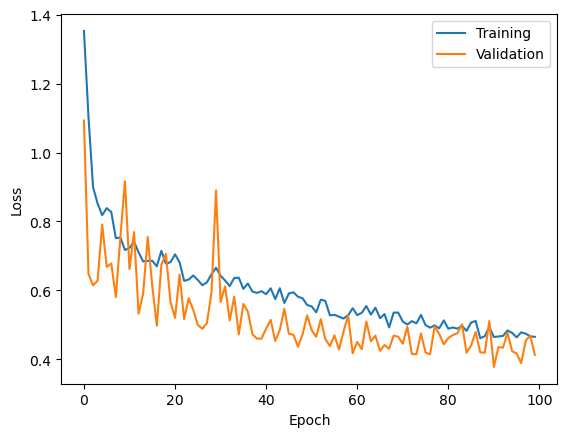

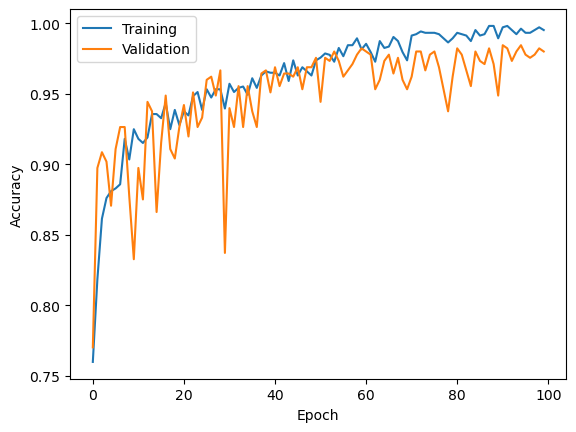

In [8]:
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
 
plt.plot(history['acc'], label='Training')
plt.plot(history['val_acc'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [8]:
history = train(train_dl, val_dl, net, criterion, opt, n_epochs, device)

Epoch 1/100:   3%|██▍                                                                         | 1/32 [00:00<?, ?step/s]C:\Users\conon\AppData\Local\Temp\ipykernel_20328\1218273706.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:178.)
  sample = torch.from_numpy(np.load(file_path, mmap_mode='r'))
Epoch 1/100: : 33step [00:34,  1.06s/step, acc=0.625, loss=1.45]                                                       
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.49it/s]


loss=1.2078, acc=0.7324, val_loss=0.7498, val_acc=0.8504


Epoch 2/100: : 33step [00:29,  1.10step/s, acc=0.875, loss=0.599]                                                      
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.43it/s]


loss=0.7894, acc=0.8311, val_loss=0.6518, val_acc=0.8750


Epoch 3/100: : 33step [00:30,  1.05step/s, acc=0.75, loss=0.902]                                                       
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.45it/s]


...

loss=0.3772, acc=0.9922, val_loss=0.4425, val_acc=0.9665


Epoch 99/100: : 33step [00:29,  1.07step/s, acc=1, loss=0.371]                                                         
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.34it/s]


loss=0.3824, acc=0.9912, val_loss=0.4228, val_acc=0.9710


Epoch 100/100: : 33step [00:29,  1.07step/s, acc=1, loss=0.386]                                                        
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.45it/s]


loss=0.3852, acc=0.9922, val_loss=0.5069, val_acc=0.9665


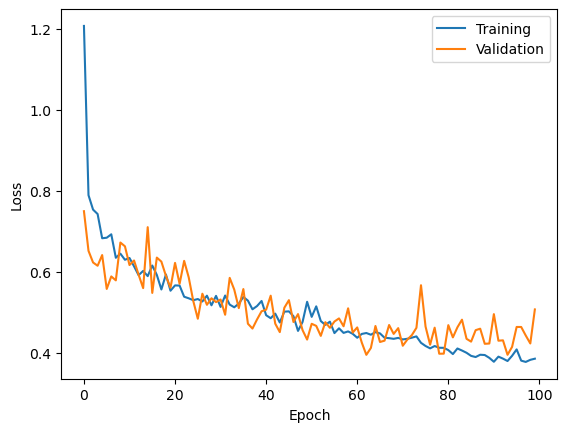

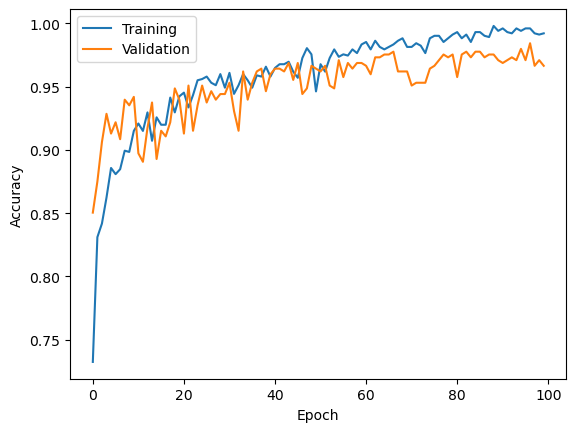

In [9]:
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
 
plt.plot(history['acc'], label='Training')
plt.plot(history['val_acc'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [7]:
history = train(train_dl, val_dl, net, criterion, opt, n_epochs, device)

Epoch 1/100:   3%|██▍                                                                         | 1/32 [00:00<?, ?step/s]C:\Users\conon\AppData\Local\Temp\ipykernel_10788\1218273706.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:178.)
  sample = torch.from_numpy(np.load(file_path, mmap_mode='r'))
Epoch 1/100: : 33step [00:38,  1.19s/step, acc=0.812, loss=1.16]                                                       
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.12it/s]


loss=1.6636, acc=0.7441, val_loss=1.4518, val_acc=0.7054


Epoch 2/100: : 33step [00:31,  1.02step/s, acc=0.875, loss=0.898]                                                      
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.19it/s]


loss=1.0353, acc=0.8418, val_loss=0.6587, val_acc=0.8906


Epoch 3/100: : 33step [00:32,  1.02s/step, acc=0.938, loss=0.75]                                                       
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.28it/s]


...

loss=0.4533, acc=0.9961, val_loss=0.4328, val_acc=0.9665


Epoch 99/100: : 33step [00:31,  1.01step/s, acc=1, loss=0.446]                                                         
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.40it/s]


loss=0.4545, acc=0.9971, val_loss=0.4338, val_acc=0.9754


Epoch 100/100: : 33step [00:30,  1.04step/s, acc=0.969, loss=0.465]                                                    
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.42it/s]


loss=0.4634, acc=0.9941, val_loss=0.4848, val_acc=0.9643


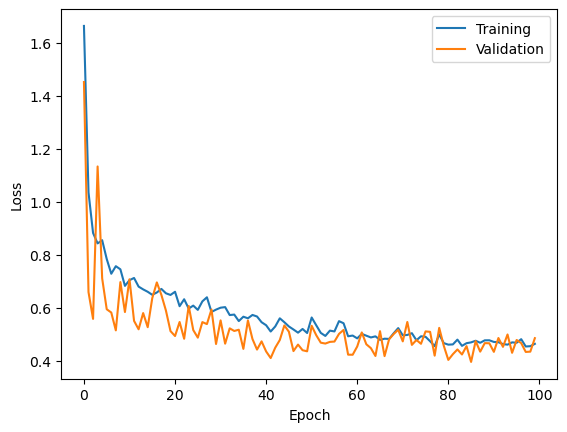

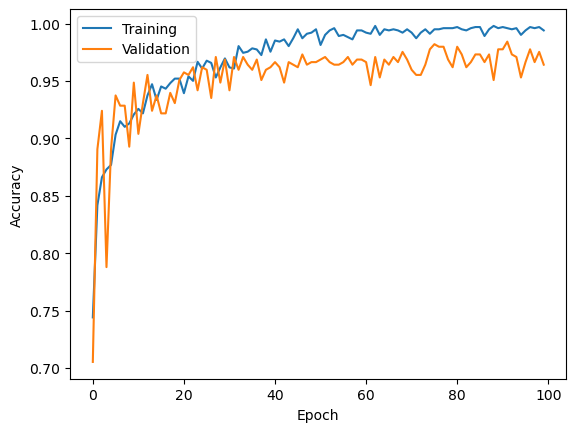

In [8]:
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
 
plt.plot(history['acc'], label='Training')
plt.plot(history['val_acc'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [7]:
history = train(train_dl, val_dl, net, criterion, opt, n_epochs, device)

Epoch 1/10:   3%|██▍                                                                          | 1/32 [00:00<?, ?step/s]C:\Users\conon\AppData\Local\Temp\ipykernel_15924\1218273706.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:178.)
  sample = torch.from_numpy(np.load(file_path, mmap_mode='r'))
Epoch 1/10: : 33step [00:10,  2.95step/s, acc=0.938, loss=0.41]                                                        
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:02<00:00,  5.88it/s]


loss=0.7285, acc=0.6709, val_loss=0.4303, val_acc=0.8705


Epoch 2/10: : 33step [00:05,  6.08step/s, acc=0.812, loss=0.341]                                                       
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 12.89it/s]


loss=0.3427, acc=0.8906, val_loss=0.3526, val_acc=0.7634


Epoch 3/10: : 33step [00:05,  6.11step/s, acc=1, loss=0.105]                                                           
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 12.43it/s]


...

loss=0.0891, acc=0.9766, val_loss=0.0824, val_acc=0.9688


Epoch 9/10: : 33step [00:05,  5.70step/s, acc=1, loss=0.0278]                                                          
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 13.22it/s]


loss=0.0872, acc=0.9746, val_loss=0.0658, val_acc=0.9933


Epoch 10/10: : 33step [00:04,  6.43step/s, acc=1, loss=0.0181]                                                         
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 12.98it/s]

loss=0.0745, acc=0.9805, val_loss=0.0578, val_acc=0.9911


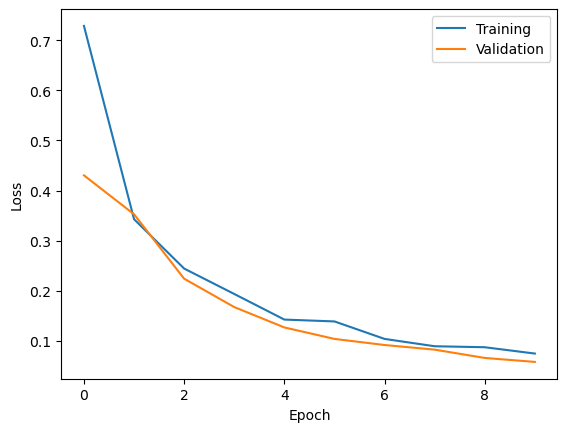

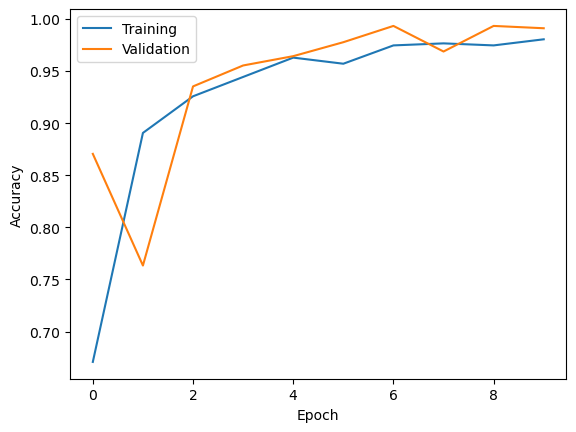

In [8]:
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
 
plt.plot(history['acc'], label='Training')
plt.plot(history['val_acc'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [7]:
history = train(train_dl, val_dl, net, criterion, opt, n_epochs, device)

Epoch 1/10:   3%|██▍                                                                          | 1/32 [00:00<?, ?step/s]C:\Users\conon\AppData\Local\Temp\ipykernel_884\1218273706.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:178.)
  sample = torch.from_numpy(np.load(file_path, mmap_mode='r'))
Epoch 1/10: : 33step [00:07,  4.28step/s, acc=0.938, loss=0.29]                                                        
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 13.59it/s]


loss=0.4453, acc=0.8115, val_loss=0.7899, val_acc=0.6696


Epoch 2/10: : 33step [00:04,  6.57step/s, acc=1, loss=0.122]                                                           
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 13.50it/s]


loss=0.1917, acc=0.9502, val_loss=0.1532, val_acc=0.9888


Epoch 3/10: : 33step [00:04,  6.59step/s, acc=1, loss=0.0607]                                                          
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 13.38it/s]


...

loss=0.0888, acc=0.9785, val_loss=0.0845, val_acc=0.9911


Epoch 8/10: : 33step [00:04,  6.61step/s, acc=1, loss=0.0653]                                                          
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 13.44it/s]


loss=0.0853, acc=0.9834, val_loss=0.0550, val_acc=0.9888


Epoch 9/10: : 33step [00:04,  6.65step/s, acc=1, loss=0.042]                                                           
Validation: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 13.44it/s]

loss=0.0630, acc=0.9854, val_loss=0.1409, val_acc=0.9375


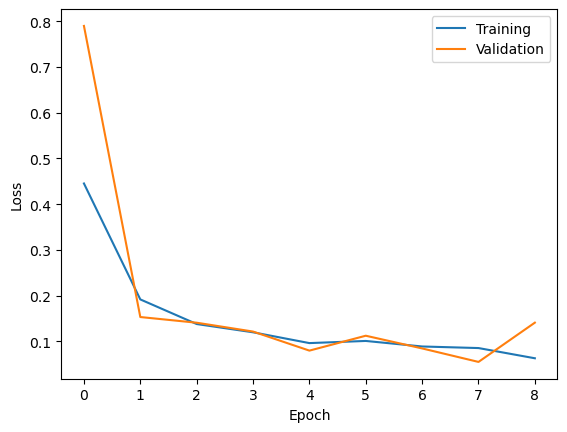

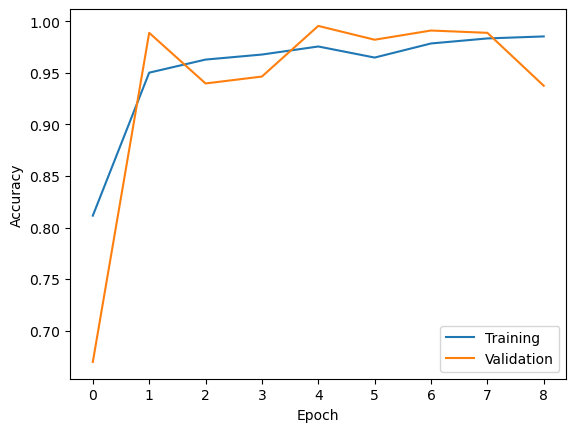

In [9]:
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
 
plt.plot(history['acc'], label='Training')
plt.plot(history['val_acc'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [32]:
inp, lbl = next(generator(val_dl))
inp = inp.to(device, dtype=torch.float32)
lbl = lbl.to(device)

In [33]:
torch.argmax(net(inp), 1)

tensor([1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 0, 0, 2, 2, 2, 1, 2, 1, 0, 1, 0, 1, 2, 2,
        1, 2, 1, 0, 0, 0, 0, 2], device='cuda:0')

In [34]:
lbl

tensor([1, 1, 0, 1, 2, 0, 2, 2, 1, 1, 0, 0, 2, 2, 2, 1, 2, 1, 0, 1, 0, 1, 2, 2,
        1, 2, 1, 0, 0, 0, 0, 2], device='cuda:0', dtype=torch.int32)

In [35]:
torch.argmax(net(inp), 1) == lbl

tensor([ True,  True, False,  True,  True, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True], device='cuda:0')